In [ ]:
# TODO: clean up code
# TODO: what happens if I Train for certain block size and then extend
# TODO: review reshapes vs views
# TODO: review permutes
# TODO: go deeper by removing F. and nn layers
# TODO: how to increase sample efficiency with stride
# TODO: can we use openwebtext?
# TODO: count model params, count number tokens, do chinchila math
# TODO: check dropout in action
# TODO: manual dropout implementation, check we have same results
# TODO: try removing special chars (replacing with closest)
# TODO: try word tokenization
# TODO: try subword tokenization (lowercase)
# TODO: try custom tokenization
# TODO: inference should only require previous hidden state, not the whole token sequence
# TODO: test if perplexity is constant when loss ranges are different
# TODO: measure token/s during training (take into account block size, batch size, gradient checkpointing, etc)

In [2]:
# NOTE: this config reaches 1.232 val loss on LOTR
CONFIG = {
    "seed" : 42,
    "block_size" : 64, # TODO: increase block size?
    "n_embed" : 128, # TODO: decrease embed size?
    "batch_size" : 64,
    "hidden_size" : 1024,
    "n_epochs" : 50,
    "learning_rate" : 0.5e-3,
    "patience" : 10,  # Increased from 3 - allow more epochs for convergence
    "early_stop_threshold" : 0.0,  # Changed from 0.001 - any improvement counts
    "dropout" : 0.2
}

In [3]:
from lightning.pytorch import seed_everything

seed_everything(CONFIG["seed"], workers=True)

Seed set to 42


42

In [4]:
import torch
DEVICE = torch.device("cuda")

In [5]:
with open("data/lotr.txt", "r", encoding="utf-8") as f: TEXT = f.read()
TEXT = TEXT.lower()
TEXT[:10000]

'####-special note: \n\n \nin this reprint several minor inaccuracies, most of them noted by readers, have \nbeen corrected. for example, the rune text now corresponds exactly with the runes \non  thror\'s  map.  more  important  is  the  matter  of  chapter  five.  there  the  true \nstory  of  the  ending  of  the  riddle  game,  as  it  was  eventually  revealed  (under \npressure)  by bilbo  to gandalf,  is  now  given  according  to  the red book,  in  place \nof  the  version  bilbo  first  gave  to  his  friends,  and  actually  set  down  in  his  diary. \nthis  departure  from  truth  on  the  part  of  a  most  honest  hobbit  was  a  portent  of \ngreat  significance.  it  does  not,  however,  concern  the  present  story,  and  those who \nin this edition make their first acquaintance with hobbit-lore need not troupe about \nit.  its  explanation  lies in the history of the ring, as it was set out in the chronicles \nof the red book of westmarch, and is now told in the lor

In [6]:
VOCAB = sorted(list(set(TEXT)))
CONFIG["vocab_size"] = len(VOCAB)
len(VOCAB), VOCAB

(73,
 ['\n',
  ' ',
  '!',
  '"',
  '#',
  '&',
  "'",
  '(',
  ')',
  '*',
  ',',
  '-',
  '.',
  '/',
  '0',
  '1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  ':',
  ';',
  '<',
  '=',
  '>',
  '?',
  '_',
  '`',
  'a',
  'b',
  'c',
  'd',
  'e',
  'f',
  'g',
  'h',
  'i',
  'j',
  'k',
  'l',
  'm',
  'n',
  'o',
  'p',
  'q',
  'r',
  's',
  't',
  'u',
  'v',
  'w',
  'x',
  'y',
  'z',
  '}',
  '¢',
  '¤',
  '¥',
  '«',
  '®',
  'µ',
  '»',
  'ó',
  '–',
  '—',
  '‘',
  '’',
  '‚',
  '…'])

In [7]:
import unicodedata

# Optional extra mappings for characters that normalization may drop
EXTRA_MAP = {
    "ð": "d",
    "þ": "th",
    "ß": "ss",
    "ø": "o",
    "ł": "l",
    "⁄": "/",
}

def to_ascii(text: str) -> str:
    # First, apply manual replacements
    for k, v in EXTRA_MAP.items():
        text = text.replace(k, v)

    # Normalize and strip accents
    normalized = unicodedata.normalize("NFKD", text)
    ascii_text = normalized.encode("ascii", "ignore").decode("ascii")

    return ascii_text

print(to_ascii("áâä éêë íî ð óô úû ý ⁄ café naïve"))

aaa eee ii d oo uu y / cafe naive


In [8]:
TEXT_ASCII = to_ascii(TEXT)
VOCAB = sorted(list(set(TEXT_ASCII)))
CONFIG["vocab_size"] = len(VOCAB)
len(VOCAB), VOCAB

(59,
 ['\n',
  ' ',
  '!',
  '"',
  '#',
  '&',
  "'",
  '(',
  ')',
  '*',
  ',',
  '-',
  '.',
  '/',
  '0',
  '1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  ':',
  ';',
  '<',
  '=',
  '>',
  '?',
  '_',
  '`',
  'a',
  'b',
  'c',
  'd',
  'e',
  'f',
  'g',
  'h',
  'i',
  'j',
  'k',
  'l',
  'm',
  'n',
  'o',
  'p',
  'q',
  'r',
  's',
  't',
  'u',
  'v',
  'w',
  'x',
  'y',
  'z',
  '}'])

In [9]:
ctoi = dict((c, i) for i, c in enumerate(VOCAB))
itoc = dict((i, c) for i, c in enumerate(VOCAB))
encode = lambda str: [ctoi[c] for c in str]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
decode(encode("hello world"))

'hello world'

In [10]:
#import tiktoken
#enc = tiktoken.get_encoding("gpt2")
#CONFIG["vocab_size"] = enc.n_vocab
#encode = enc.encode
#decode = enc.decode
#enc.n_vocab, decode(encode("hello world"))

In [11]:
TOKENS = encode(TEXT_ASCII)
TOKENS[:10]

[4, 4, 4, 4, 11, 50, 47, 36, 34, 40]

In [12]:
import torch
from torch.utils.data import Dataset

class ChunkedDataset(Dataset):
    def __init__(self, tokens, block_size=CONFIG["block_size"]):
        tokens = torch.tensor(tokens)

        n_chunks = (len(tokens)) // (block_size + 1)
        tokens = tokens[:n_chunks * (block_size + 1)]

        self.chunks = tokens.view(n_chunks, block_size + 1)

    def __getitem__(self, idx):
        chunk = self.chunks[idx]
        x = chunk[:-1]
        y = chunk[1:]
        return x, y

    def __len__(self):
        return len(self.chunks)

full_dataset = ChunkedDataset(TOKENS)
full_dataset[0]

(tensor([ 4,  4,  4,  4, 11, 50, 47, 36, 34, 40, 32, 43,  1, 45, 46, 51, 36, 24,
          1,  0,  0,  1,  0, 40, 45,  1, 51, 39, 40, 50,  1, 49, 36, 47, 49, 40,
         45, 51,  1, 50, 36, 53, 36, 49, 32, 43,  1, 44, 40, 45, 46, 49,  1, 40,
         45, 32, 34, 34, 52, 49, 32, 34, 40, 36]),
 tensor([ 4,  4,  4, 11, 50, 47, 36, 34, 40, 32, 43,  1, 45, 46, 51, 36, 24,  1,
          0,  0,  1,  0, 40, 45,  1, 51, 39, 40, 50,  1, 49, 36, 47, 49, 40, 45,
         51,  1, 50, 36, 53, 36, 49, 32, 43,  1, 44, 40, 45, 46, 49,  1, 40, 45,
         32, 34, 34, 52, 49, 32, 34, 40, 36, 50]))

In [13]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(
    full_dataset, 
    [int(len(full_dataset) * 0.8), len(full_dataset) - int(len(full_dataset) * 0.8)]
)

In [14]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=CONFIG["batch_size"]
)
for x, y in train_dataloader:
    print("X:", x.shape)
    print("Y:", y.shape)
    break

X: torch.Size([64, 64])
Y: torch.Size([64, 64])


In [15]:
from torch.utils.data import DataLoader

val_dataloader = DataLoader(
    val_dataset,
    shuffle=False,
    batch_size=CONFIG["batch_size"]
)
for x, y in val_dataloader:
    print("X:", x.shape)
    print("Y:", y.shape)
    break

X: torch.Size([64, 64])
Y: torch.Size([64, 64])


In [16]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(
        self, 
        vocab_size=CONFIG["vocab_size"], 
        n_embed=CONFIG["n_embed"], 
        hidden_size=CONFIG["hidden_size"],
        dropout=CONFIG["dropout"]
    ):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.embeddings = nn.Embedding(vocab_size, n_embed) # TODO: do manually
        self.dropout_emb = nn.Dropout(dropout) if dropout else nn.Identity()
        self.W_x = nn.Linear(n_embed, hidden_size)#, bias=False) # TODO: do manually
        self.W_h = nn.Linear(hidden_size, hidden_size)#, bias=False)

        self.dropout_out = nn.Dropout(dropout) if dropout else nn.Identity()
        #self.bias = nn.Parameter(torch.zeros(hidden_size))

        # TODO: how does this optim wokr
        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        #self.head.weight = self.embeddings.weight
    
    def forward(self, x, hidden_state=None):
        B, T = x.shape
        x_emb = self.embeddings(x) # (B, T) -> (B, T, C)
        x_emb = self.dropout_emb(x_emb)
        x_transf = self.W_x(x_emb) # (B, T, C) -> (B, T, H)
        ht_prev = torch.zeros(B, self.hidden_size).to(x.device) if hidden_state is None else hidden_state # (B, H)
        hts = []
        for t in range(T):
            xt = x_transf[:,t,:] # (B, T, H) -> (B, H)
            ht = self.W_h(ht_prev) # (B, H) -> (B, H)
            out = torch.tanh(xt + ht) # (B, H) + (B, H) -> (B, H)
            hts.append(out)
            ht_prev = out
        outs = torch.stack(hts, dim=1).to(x.device) # (B, T, H)

        outs = self.dropout_out(outs)
        logits = self.head(outs) # (B, T, H) -> (B, T, C)
        return logits, hts
    
    # TODO: expected this to be faster but its not, investigate
    def _forward(self, x):
        B, T = x.shape
        x_emb = self.embeddings(x)
        x_transf = self.W_x(x_emb)
        h = torch.zeros(B, T, self.hidden_size, device=x.device)  # Add device
        h_prev = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h_t = torch.tanh(x_transf[:, t] + self.W_h(h_prev))  # Compute first
            h[:, t] = h_t  # Then assign (separate operations)
            h_prev = h_t   # Then update
        logits = self.head(h)
        return logits

model = RNN().to(DEVICE)
x, _ = next(iter(train_dataloader)) # TODO: what does this mean?
x = x.to(DEVICE)
logits, _ = model(x)
x.shape, logits.shape

(torch.Size([64, 64]), torch.Size([64, 64, 59]))

In [17]:
from tqdm import tqdm
import torch.nn.functional as F

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    losses = []
    device = next(model.parameters()).device
    for x, y in tqdm(loader, disable=True):
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        logits = logits.reshape(-1, logits.size(-1)) # (B,T,V) -> (B*T,V)
        y = y.reshape(-1) # (B,T) -> (B*T)
        loss = F.cross_entropy(logits, y) # TODO: do manually
        loss_i = loss.item()
        losses.append(loss_i)
    loss = sum(losses) / len(loader)
    return loss

evaluate(model, val_dataloader)

4.114295673977797

In [18]:
import time 

def generate(model, prompt, max_len=100):
    model.eval()
    tokens = encode(prompt)
    max_len = max_len - len(tokens)
    assert max_len > 0
    print(prompt, end="")
    device = next(model.parameters()).device
    
    # Process the prompt once to get initial hidden state
    tokens_t = torch.tensor(tokens).unsqueeze(0).to(device)  # (1, T_prompt)
    logits, hts = model(tokens_t, hidden_state=None)
    hidden_state = hts[-1]  # (B, H) - final hidden state after processing prompt
    
    start = time.time()
    n_gen = 0
    for _ in range(max_len):
        # Sample from the last token's logits
        logits_last = logits[:, -1, :]  # (B, T, C) -> (B, C)
        probs = F.softmax(logits_last, dim=-1)  # (B, C) -> (B, P)
        token = torch.multinomial(probs, num_samples=1).squeeze().item()
        
        # Generate next logits by passing only the new token with hidden state
        token_t = torch.tensor([[token]]).to(device)  # (1, 1) - single token
        logits, hts = model(token_t, hidden_state=hidden_state)
        hidden_state = hts[-1]  # Update hidden state for next iteration
        
        n_gen += 1
        token_s = decode([token])
        print(token_s, end="")
    
    end = time.time()
    elapsed = end - start
    tps = n_gen / elapsed
    print(f"\ntps: {tps:.2f}")

generate(model, "frodo picked up the ")

frodo picked up the -_uei'2>&1ua(!4}&3fvtkke_h2ux21r'ef,bjr8'>!6fg99te3>(</`*49s_w=3pz1i;737a*"fxyn5
tps: 337.04


In [19]:
import numpy as np
def calculate_perplexity(model, loader):
    """Calculate perplexity (lower is better)"""
    model.eval()
    total_loss = 0
    total_tokens = 0
    
    device = next(model.parameters()).device
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits, _ = model(x)
            logits = logits.reshape(-1, logits.size(-1))
            y = y.reshape(-1)
            loss = F.cross_entropy(logits, y)
            total_loss += loss.item() * len(y)
            total_tokens += len(y)
    
    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)
    return perplexity, avg_loss

# Calculate perplexity
train_perplexity, train_loss = calculate_perplexity(model, train_dataloader)
val_perplexity, val_loss = calculate_perplexity(model, val_dataloader)

print(f"Train perplexity: {train_perplexity:.2f}")
print(f"Val perplexity: {val_perplexity:.2f}")

# Interpretation:
# - Perplexity close to vocab_size: Model is essentially random
# - Perplexity << vocab_size: Model is learning patterns
# - If val_perplexity >> train_perplexity: Overfitting
# - If both are high and close: Underfitting (not enough capacity)

Train perplexity: 61.20
Val perplexity: 61.21


In [20]:
def cross_entropy_loss(logits, targets):
    """
    Custom cross-entropy loss - most explicit version.
    
    Args:
        logits: (N, C) tensor where N is batch size, C is number of classes
        targets: (N,) tensor of class indices (long/int64)
    
    Returns:
        scalar loss value
    """
    # Step 1: Apply softmax to get probabilities
    # exp_logits = exp(logits)
    exp_logits = logits.exp()  # (N, C)
    
    # sum_exp = sum(exp(logits)) for each sample
    sum_exp = exp_logits.sum(dim=1, keepdim=True)  # (N, 1)
    
    # probs = exp(logits) / sum(exp(logits))
    probs = exp_logits / sum_exp  # (N, C)
    
    # Step 2: Get probability of true class for each sample
    # probs[i, targets[i]] for each i
    true_class_probs = probs.gather(1, targets.unsqueeze(1)).squeeze(1)  # (N,)
    
    # Step 3: Take negative log
    log_probs = true_class_probs.log()  # (N,)
    
    # Step 4: Average (cross-entropy is negative log likelihood)
    loss = -log_probs.mean()
    
    return loss

In [21]:
import time
import torch.optim
import torch.nn.functional as F

start = time.time()
n_epochs = CONFIG["n_epochs"]
lr = CONFIG["learning_rate"]
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
train_losses = []
val_losses = []
train_loss = None
val_loss = None
postfix = dict(train_loss=train_loss,val_loss=val_loss)
patience = max_patience = CONFIG["patience"]
early_stop_threshold = CONFIG["early_stop_threshold"]
device = next(model.parameters()).device
best_val_loss = 999999999
for _ in range(n_epochs):
    model.train()
    losses = []
    pbar = tqdm(train_dataloader)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        # TODO: why view doesnt work?
        logits = logits.reshape(-1, logits.size(-1)) # (B,T,V) -> (B*T,V)
        y = y.reshape(-1) # (B,T) -> (B*T)
        loss = F.cross_entropy(logits, y) # TODO: do manually
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_i = loss.item()
        losses.append(loss_i)
        _postfix = dict([(k,v) for k,v in postfix.items() if v is not None])
        pbar.set_postfix(_postfix)
    val_loss = evaluate(model, val_dataloader)
    train_loss = sum(losses) / len(losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    postfix["train_loss"] = train_loss
    postfix["val_loss"] = val_loss
    postfix["patience"] = patience
    _postfix = dict([(k,v) for k,v in postfix.items() if v is not None])
    pbar.set_postfix(_postfix)

    if len(val_losses) > 1:
        # Calculate improvement BEFORE updating best_val_loss
        val_loss_delta = best_val_loss - val_loss

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # ANY improvement resets patience (don't gate on threshold)
            patience = max_patience
            if val_loss_delta > early_stop_threshold:
                print(f"Patience reset, val_loss_delta = {val_loss_delta:.4f} (significant improvement)")
            else:
                print(f"Patience reset, val_loss_delta = {val_loss_delta:.4f} (small improvement)")
        else:
            # No improvement - decrease patience
            patience -= 1
            print(f"Patience = {patience}, val_loss_delta = {val_loss_delta:.4f} (no improvement)")

        if patience == 0:
            print("Early stopping due to val_loss stall")
            break

train_loss = train_losses[-1]
val_loss = val_losses[-1]
elapsed = time.time() - start
print(f"Training finished in {elapsed}s")
print(f"train: {train_loss}")
print(f"val: {val_loss}")

100%|██████████| 628/628 [00:07<00:00, 80.73it/s, train_loss=1.87, val_loss=1.58, patience=10]


Patience reset, val_loss_delta = 999999997.5311 (significant improvement)


100%|██████████| 628/628 [00:07<00:00, 83.98it/s, train_loss=1.6, val_loss=1.47, patience=10]


Patience reset, val_loss_delta = 0.0492 (significant improvement)


100%|██████████| 628/628 [00:06<00:00, 91.85it/s, train_loss=1.53, val_loss=1.42, patience=10]


...

Patience = 7, val_loss_delta = -0.0032 (no improvement)


100%|██████████| 628/628 [00:07<00:00, 86.89it/s, train_loss=1.31, val_loss=1.29, patience=8]


Patience = 6, val_loss_delta = -0.0031 (no improvement)


100%|██████████| 628/628 [00:07<00:00, 85.12it/s, train_loss=1.31, val_loss=1.29, patience=7]


Patience = 5, val_loss_delta = -0.0010 (no improvement)
Training finished in 383.3963804244995s
train: 1.3099955189379917
val: 1.2834528130330858


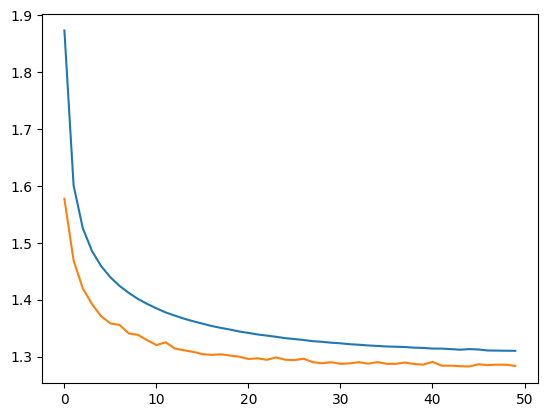

In [22]:
import matplotlib.pyplot as plt
plt.plot(train_losses) # TODO: manually plot gradnorms too
plt.plot(val_losses)

In [44]:
generate(model, "frodo picked up ", max_len=1024)

frodo picked up to fare the dnearurims and patter of  the dark lord; 
     from the name left  a  guestion  of the nemssed. out could be but not for time." 
"you were  unfurought.  'the walls of isengard of the bridge. 
 

####-<h4>chapter 5 </call, he was wrought to keep up the woods and the echo of the commbet. only to be a dark to the door. get 
them east to 
the  sorrow,  the company who took the foremorca bold  and  jowyn away 
on a 
large battle?  and the others was like try enowy tales of 
golden longs long or no 
sound,  but  the 
moment  the went of the topttil bn ome with them ord or people  and do nimoked! litely within a new small.  but  at the onger ocharach  of his 
rest, one of thes and found that he hubred he pulled here, 
     and there was a strange mighty defale of the woods, sigpon 
that they dleven 
fnew or master." 
"frodo incily, but there was no more than i am proper garrent of sauron' 
with a small  company, or clad in me. 
     'where is some long stone. and c

In [24]:
import numpy as np

def count_parameters(model):
    """Count total and trainable parameters"""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def estimate_model_capacity(model, vocab_size, hidden_size, n_embed):
    """Estimate model capacity in bits"""
    # Rough estimate: each parameter can store ~log2(vocab_size) bits of info
    total_params, trainable_params = count_parameters(model)
    capacity_bits = total_params * np.log2(vocab_size)
    return total_params, trainable_params, capacity_bits

# Count parameters
total_params, trainable_params = count_parameters(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Estimate capacity
total, trainable, capacity = estimate_model_capacity(
    model, CONFIG["vocab_size"], CONFIG["hidden_size"], CONFIG["n_embed"]
)
print(f"Estimated capacity: ~{capacity/1e6:.2f}M bits")

# Compare to dataset size
dataset_size = len(TOKENS)
print(f"Dataset size: {dataset_size:,} tokens")
print(f"Parameters per token: {total_params / dataset_size:.2f}")

# Rule of thumb:
# - < 0.1 params/token: Likely underfitting
# - 0.1-1.0 params/token: Reasonable
# - > 1.0 params/token: May overfit (depends on data quality)

Total parameters: 1,249,664
Trainable parameters: 1,249,664
Estimated capacity: ~7.35M bits
Dataset size: 3,261,838 tokens
Parameters per token: 0.38


In [25]:
import numpy as np

# Quick diagnostic
print("=" * 50)
print("MODEL CAPACITY DIAGNOSTIC")
print("=" * 50)

# 1. Parameter count
total_params, _ = count_parameters(model)
print(f"\n1. Parameters: {total_params:,}")

# 2. Loss gap
gap = train_loss - val_loss
gap_pct = (gap / train_loss) * 100
print(f"\n2. Train-Val Gap: {gap:.4f} ({gap_pct:.1f}%)")
if gap_pct < 5:
    print("   → Likely UNDERFITTING (not enough capacity)")
elif gap_pct > 20:
    print("   → Likely OVERFITTING (too much capacity or needs regularization)")
else:
    print("   → Good balance")

# 3. Learning trends
if len(train_losses) > 10:
    train_plateau = np.std(train_losses[-10:]) < 0.01
    val_plateau = np.std(val_losses[-10:]) < 0.01
    print(f"\n3. Loss stability:")
    print(f"   Train plateaued: {train_plateau}")
    print(f"   Val plateaued: {val_plateau}")
    if train_plateau and val_loss > train_loss * 1.1:
        print("   → Model may need more capacity")

# 4. Perplexity
val_perp, _ = calculate_perplexity(model, val_dataloader)
print(f"\n4. Validation Perplexity: {val_perp:.2f}")
if val_perp > CONFIG["vocab_size"] * 0.8:
    print("   → Very high perplexity, model likely underfitting")

print("\n" + "=" * 50)

MODEL CAPACITY DIAGNOSTIC

1. Parameters: 1,249,664

2. Train-Val Gap: 0.0265 (2.0%)
   → Likely UNDERFITTING (not enough capacity)

3. Loss stability:
   Train plateaued: True
   Val plateaued: True

4. Validation Perplexity: 3.61

